In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

#Cargo el dataset Iris
iris = datasets.load_iris()
#Usamos solo las columnas: longitud de sépalo y longitud de pétalo
X = iris.data[:, [0, 2]] 
y = iris.target

#Usamos el experimento B: Versicolor (clase 1) vs Virgínica (clase 2)
# Filtramos solo esas dos clases
mask_b = (y == 1) | (y == 2)
X_b, y_b = X[mask_b], y[mask_b]



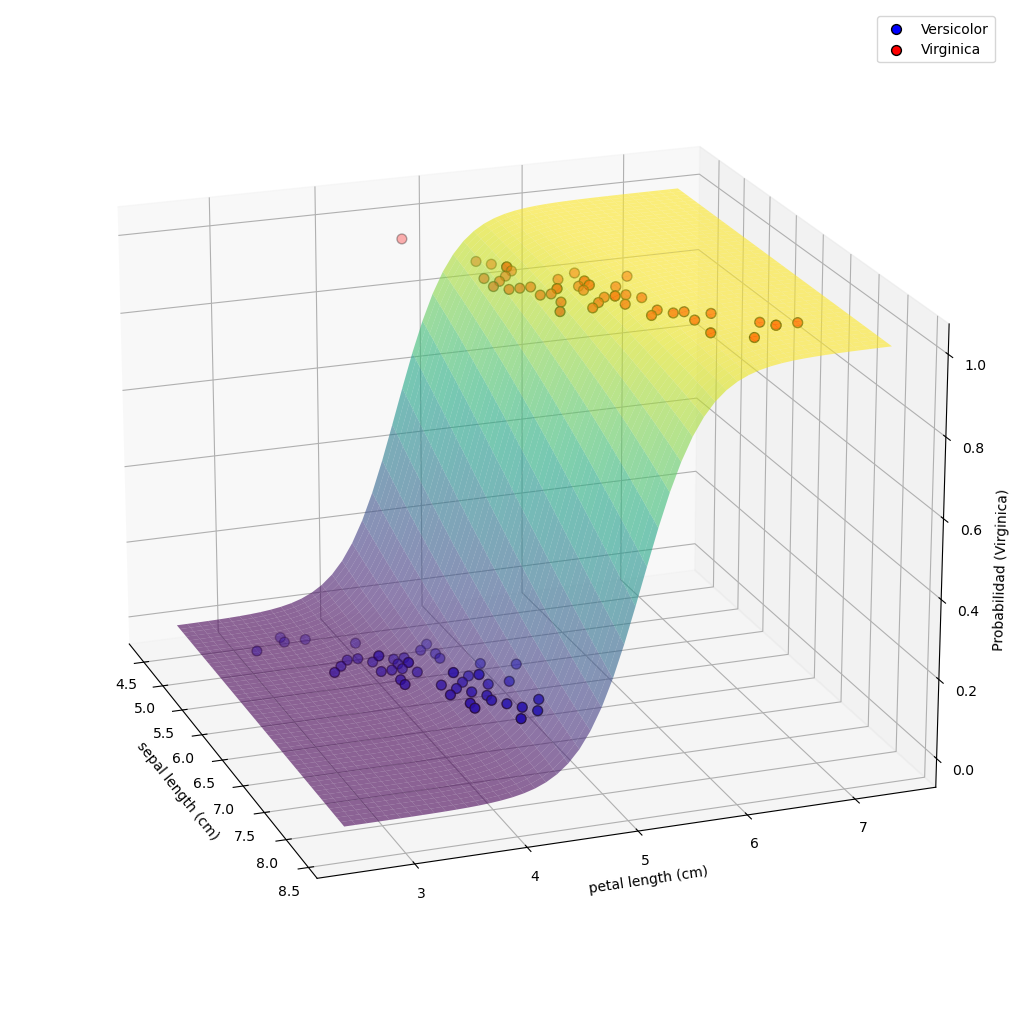

In [10]:

from sklearn.linear_model import LogisticRegression
from mpl_toolkits.mplot3d import Axes3D

y_b2 = np.where(y_b == 1, 0, 1) 
#Cambio las etiquetas a Versicolor -> 0 y Virgínica -> 1, para que la regresión logística las pueda interpretar mejor.

# 2. Entrenar el modelo de Regresión Logística
model = LogisticRegression()
model.fit(X_b, y_b2)

#Creo una malla para la superficie
x_min, x_max = X_b[:, 0].min() - 0.5, X_b[:, 0].max() + 0.5
y_min, y_max = X_b[:, 1].min() - 0.5, X_b[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 50),
                     np.linspace(y_min, y_max, 50))

#Calculamos las probabilidades para cada punto de la malla
grid_points = np.c_[xx.ravel(), yy.ravel()]
probs = model.predict_proba(grid_points)[:, 1] # Probabilidad de ser clase 1 (Virgínica)
zz = probs.reshape(xx.shape)

# Hacemos la figura 3D
fig = plt.figure(figsize=(12, 10),constrained_layout=True)
ax = fig.add_subplot(111, projection='3d')
ax.dist=18

#Dibujamos la superficie de la sigmoide
ax.plot_surface(xx, yy, zz, cmap='viridis', alpha=0.6, antialiased=True)

#Dibujamos los puntos de datos originales
ax.scatter(X_b[y_b2 == 0, 0], X_b[y_b2 == 0, 1], 0, 
           c='blue', label='Versicolor', edgecolors='k', s=50)
ax.scatter(X_b[y_b2 == 1, 0], X_b[y_b2 == 1, 1], 1, 
           c='red', label='Virginica', edgecolors='k', s=50)

ax.set_xlabel(iris.feature_names[0])
ax.set_ylabel(iris.feature_names[2])
ax.set_zlabel('Probabilidad (Virginica)')
ax.view_init(elev=20, azim=-20)
ax.legend()
plt.savefig("reglogiris.png", bbox_inches='tight',pad_inches=0.3, dpi=300)
plt.show()
